# SGV Pilot — Data Overview & Summary Statistics

**Project:** `socal_fragmentation_tax` / SGV Pilot
**Purpose:** Exploratory overview of every dataset used in the Phase 1 + 2 pipeline,
including a full pandas-profiling report on the analytical panel.

---

## Datasets covered

| # | Dataset | Source | Rows |
|---|---------|--------|------|
| 1 | Jurisdiction layer (GeoJSON) | Phase 1 · `spatial_mesh_generator` | 24 |
| 2 | Income by jurisdiction (CSV) | Phase 1 · `income_fetcher` (ACS 2023) | 24 |
| 3 | Road boundary mesh (Parquet) | Phase 1 · `spatial_mesh_generator` | 7 149 |
| 4 | Phase 2 analytical panel (Parquet) | Phase 2 · `data_prep` | 24 |
| 5 | SFA efficiency scores (CSV) | Phase 2 · `sfa` | 24 |
| 6 | LISA clusters — PCI (GeoJSON) | Phase 2 · `spatial_analysis` | 24 |


## 0  Setup

In [1]:
import warnings, pathlib
warnings.filterwarnings("ignore")

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="muted")

ROOT = pathlib.Path("data/output")
P2   = ROOT / "phase2"

print("Libraries loaded. ROOT =", ROOT.resolve())


Libraries loaded. ROOT = /home/user/TRENCH/sgv_pilot/data/output


## 1  Load All Datasets

In [2]:
# 1  Jurisdiction layer (spatial + income merged)
jur = gpd.read_file(ROOT / "san_gabriel_valley_jurisdictions.geojson")

# 2  Income CSV (flat, no geometry)
income = pd.read_csv(ROOT / "income_by_jurisdiction.csv")

# 3  Road boundary mesh
mesh = pd.read_parquet(ROOT / "san_gabriel_valley_boundary_mesh.parquet")

# 4  Phase 2 analytical panel (city-level, all model variables)
panel = pd.read_parquet(P2 / "panel_data.parquet")

# 5  SFA efficiency scores
sfa = pd.read_csv(P2 / "sfa_efficiency_scores.csv")

# 6  LISA clusters for PCI
lisa = gpd.read_file(P2 / "lisa_clusters_pci_score.geojson")

datasets = {
    "Jurisdiction layer":   jur.drop(columns="geometry"),
    "Income by city":       income,
    "Road mesh":            mesh,
    "Phase 2 panel":        panel,
    "SFA efficiency":       sfa,
    "LISA clusters (PCI)":  lisa.drop(columns="geometry"),
}

for name, df in datasets.items():
    print(f"  {name:<28}  {df.shape[0]:>5} rows × {df.shape[1]:>2} cols")


  Jurisdiction layer               24 rows × 12 cols
  Income by city                   24 rows ×  8 cols
  Road mesh                      7149 rows ×  9 cols
  Phase 2 panel                    24 rows × 24 cols
  SFA efficiency                   24 rows ×  9 cols
  LISA clusters (PCI)              24 rows ×  7 cols


## 2  Schema Overview

In [3]:
def schema_summary(name, df):
    """Print dtypes, non-null counts, and sample values for a DataFrame."""
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    info = pd.DataFrame({
        "dtype":    df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "null_pct": (df.isna().mean() * 100).round(1),
        "sample":   df.iloc[0] if len(df) > 0 else pd.Series(dtype=object),
    })
    print(info.to_string())

for name, df in datasets.items():
    schema_summary(name, df)



  Jurisdiction layer
                          dtype  non_null  null_pct                sample
jurisdiction_id          object        24       0.0               0600884
name                     object        24       0.0              Alhambra
area_sq_mi              float64        24       0.0                   7.6
city_class               object        24       0.0          Full-Service
jurisdictional_density  float64        24       0.0                  3.82
median_hh_income          int32        24       0.0                 61542
per_capita_income         int32        24       0.0                 25100
poverty_rate            float64        24       0.0                  13.4
acs_year                  int32        24       0.0                  2023
source                   object        24       0.0  synthetic_quickfacts
income_quartile          object        24       0.0                Q1_low
median_hh_income_z      float64        24       0.0                -1.023

  Income by cit

## 3  Jurisdiction Layer

In [4]:
jur_df = jur.drop(columns="geometry")
display(jur_df[[
    "name", "city_class", "area_sq_mi", "jurisdictional_density",
    "median_hh_income", "per_capita_income", "poverty_rate",
    "income_quartile", "median_hh_income_z"
]].sort_values("median_hh_income", ascending=False).reset_index(drop=True))


,name,city_class,area_sq_mi,jurisdictional_density,median_hh_income,per_capita_income,poverty_rate,income_quartile,median_hh_income_z
0,Diamond Bar,Full-Service,14.9,5.09,105831,40200,5.4,Q4_high,1.994
1,La Verne,Full-Service,12.5,6.37,100625,41500,5.1,Q4_high,1.639
2,San Dimas,Full-Service,15.4,5.09,97553,40900,5.8,Q4_high,1.430
3,Arcadia,Full-Service,11.1,5.09,96028,44800,7.6,Q4_high,1.326
4,Glendora,Full-Service,19.3,5.09,94417,38700,5.9,Q4_high,1.216
5,Temple City,Full-Service,3.9,5.09,85417,33500,7.2,Q4_high,0.603
6,Industry,Contract,12.0,6.37,85000,42000,4.0,Q3_mid_high,0.575
7,Whittier,Full-Service,14.8,3.82,84432,31900,8.6,Q3_mid_high,0.536
8,West Covina,Full-Service,16.0,5.09,83269,29300,9.4,Q3_mid_high,0.457
9,Monrovia,Full-Service,13.7,6.37,82411,34600,8.7,Q3_mid_high,0.398


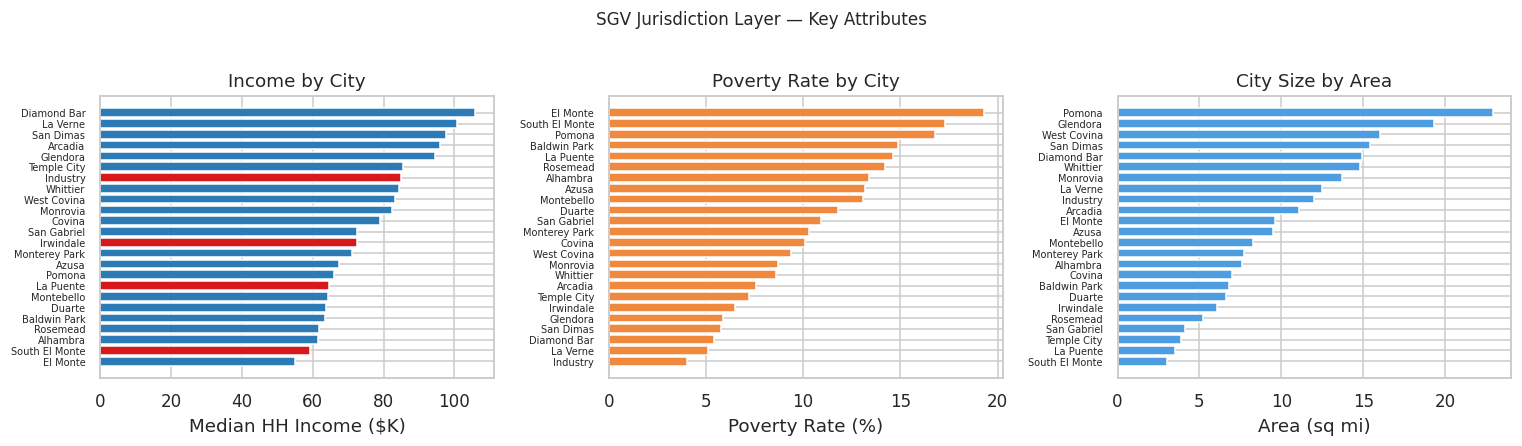

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Income distribution
axes[0].barh(
    jur_df.sort_values("median_hh_income")["name"],
    jur_df.sort_values("median_hh_income")["median_hh_income"] / 1000,
    color=["#d7191c" if c == "Contract" else "#2c7bb6"
           for c in jur_df.sort_values("median_hh_income")["city_class"]],
)
axes[0].set_xlabel("Median HH Income ($K)")
axes[0].set_title("Income by City")
axes[0].tick_params(axis="y", labelsize=6.5)

# Poverty rate
axes[1].barh(
    jur_df.sort_values("poverty_rate")["name"],
    jur_df.sort_values("poverty_rate")["poverty_rate"],
    color="#f0883e",
)
axes[1].set_xlabel("Poverty Rate (%)")
axes[1].set_title("Poverty Rate by City")
axes[1].tick_params(axis="y", labelsize=6.5)

# Area
axes[2].barh(
    jur_df.sort_values("area_sq_mi")["name"],
    jur_df.sort_values("area_sq_mi")["area_sq_mi"],
    color="#4d9de0",
)
axes[2].set_xlabel("Area (sq mi)")
axes[2].set_title("City Size by Area")
axes[2].tick_params(axis="y", labelsize=6.5)

plt.suptitle("SGV Jurisdiction Layer — Key Attributes", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## 4  Road Boundary Mesh

In [6]:
print(f"Total road segments : {len(mesh):,}")
print(f"Boundary segments   : {mesh['is_boundary'].sum():,}  ({mesh['is_boundary'].mean()*100:.1f}%)")
print()
print(mesh.describe().T[["count","mean","std","min","50%","max"]].round(3))


Total road segments : 7,149
Boundary segments   : 37  (0.5%)

              count      mean       std    min       50%       max
osmid        7149.0  3574.000  2063.883  0.000  3574.000  7148.000
boundary_mi  7149.0     0.315     0.029  0.286     0.287     0.345


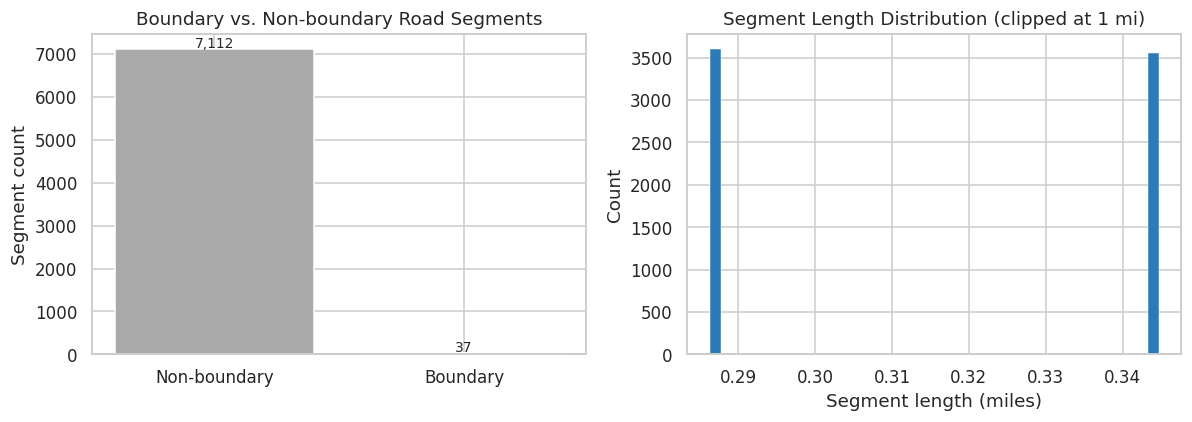

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boundary vs non-boundary
axes[0].bar(["Non-boundary", "Boundary"],
            [mesh["is_boundary"].value_counts()[False],
             mesh["is_boundary"].value_counts()[True]],
            color=["#aaaaaa", "#d7191c"])
axes[0].set_ylabel("Segment count")
axes[0].set_title("Boundary vs. Non-boundary Road Segments")
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=9)

# Segment length distribution
axes[1].hist(mesh["boundary_mi"].clip(upper=1), bins=40,
             color="#2c7bb6", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Segment length (miles)")
axes[1].set_ylabel("Count")
axes[1].set_title("Segment Length Distribution (clipped at 1 mi)")

plt.tight_layout()
plt.show()


## 5  Phase 2 Analytical Panel

In [8]:
num_cols = panel.select_dtypes(include="number").columns.tolist()
display(panel[num_cols].describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
area_sq_mi,24.0,10.06,5.26,3.00,6.48,8.90,13.98,22.90
jurisdictional_density,24.0,5.20,0.83,3.82,5.09,5.09,5.41,6.37
median_hh_income,24.0,76562.00,14681.31,55017.00,64112.25,72557.00,85104.25,105831.00
per_capita_income,24.0,29362.50,8906.71,16900.00,21800.00,28550.00,35925.00,44800.00
poverty_rate,24.0,10.59,4.28,4.00,7.02,10.20,13.60,19.30
acs_year,24.0,2023.00,0.00,2023.00,2023.00,2023.00,2023.00,2023.00
median_hh_income_z,24.0,-0.00,1.00,-1.47,-0.85,-0.27,0.58,1.99
n_neighbors,24.0,5.42,1.69,3.00,5.00,5.00,5.75,8.00
boundary_share,24.0,0.79,0.16,0.50,0.77,0.79,0.85,1.00
fragmentation_idx,24.0,-0.00,0.99,-1.60,-0.18,-0.11,0.27,1.41


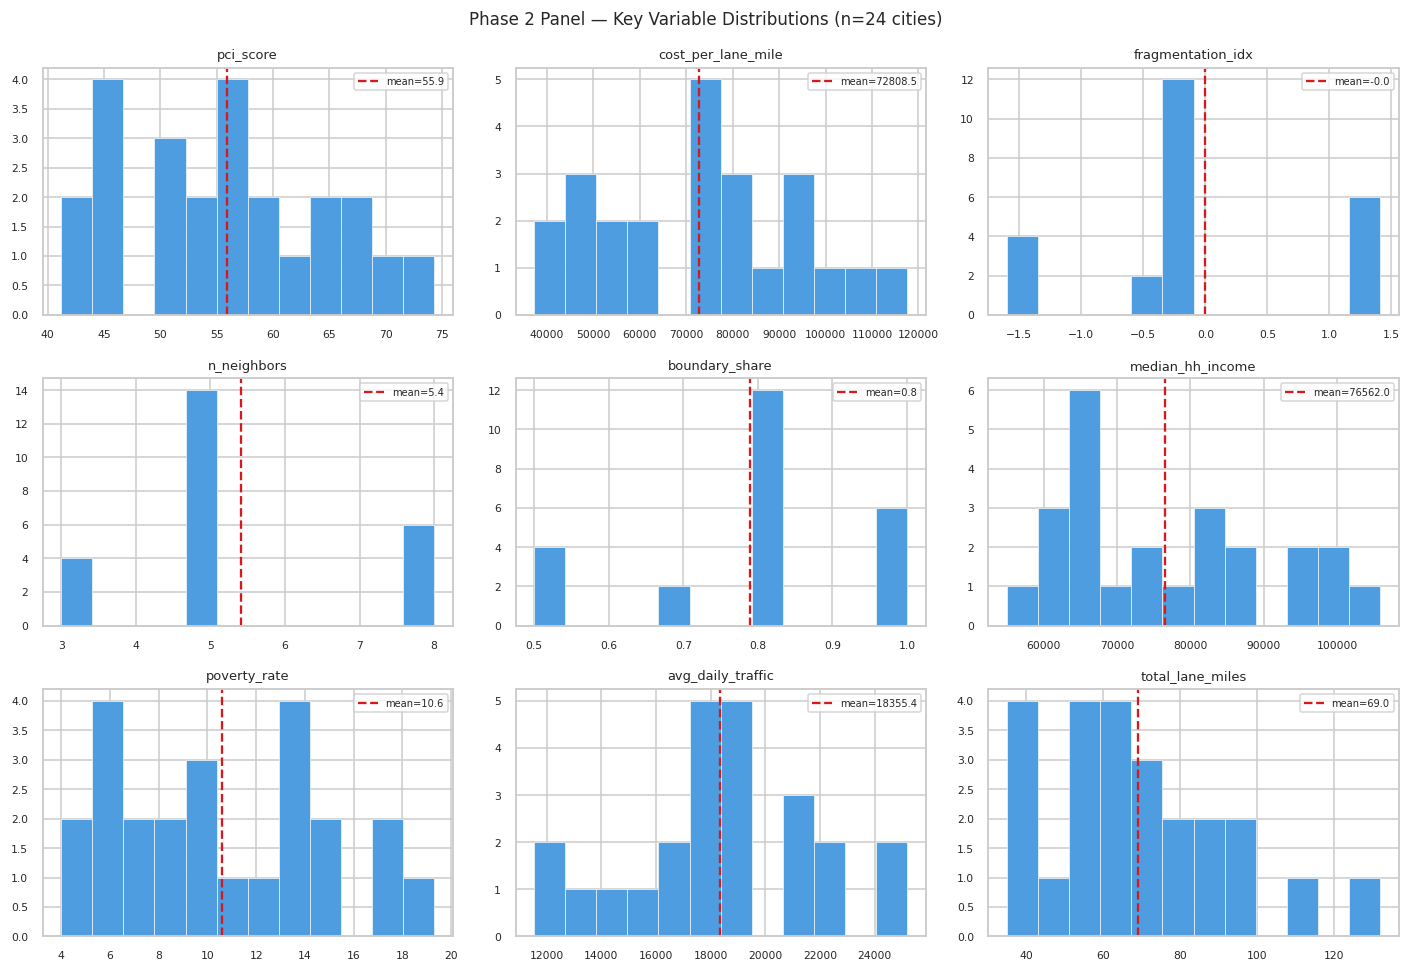

In [9]:
key_vars = ["pci_score", "cost_per_lane_mile", "fragmentation_idx",
            "n_neighbors", "boundary_share", "median_hh_income",
            "poverty_rate", "avg_daily_traffic", "total_lane_miles"]

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.flat, key_vars):
    data = panel[col].dropna()
    ax.hist(data, bins=12, color="#4d9de0", edgecolor="white", linewidth=0.4)
    ax.axvline(data.mean(), color="#d7191c", lw=1.5, ls="--", label=f"mean={data.mean():.1f}")
    ax.set_title(col, fontsize=8.5)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6.5)

plt.suptitle("Phase 2 Panel — Key Variable Distributions (n=24 cities)", fontsize=11)
plt.tight_layout()
plt.show()


## 6  Correlation Snapshot

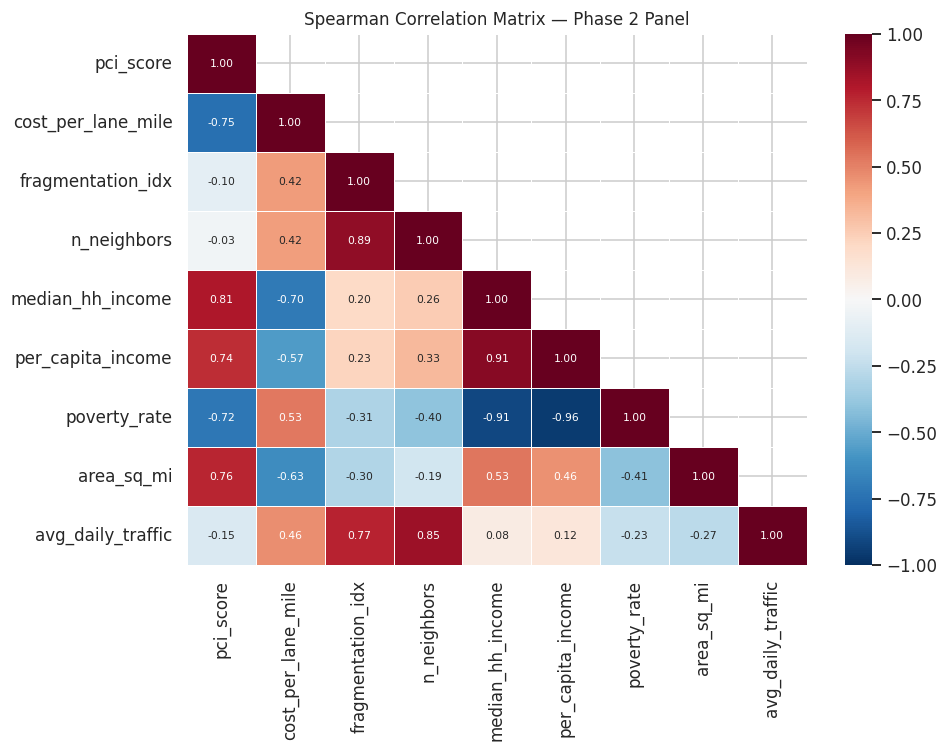


Top correlations with pci_score:
cost_per_lane_mile   -0.751
poverty_rate         -0.722
avg_daily_traffic    -0.150
fragmentation_idx    -0.100
n_neighbors          -0.032
per_capita_income     0.736
area_sq_mi            0.760
median_hh_income      0.808

Top correlations with cost_per_lane_mile:
poverty_rate         0.530
avg_daily_traffic    0.463
fragmentation_idx    0.425
n_neighbors          0.420
per_capita_income   -0.566
area_sq_mi          -0.626
median_hh_income    -0.704
pci_score           -0.751


In [10]:
corr_vars = ["pci_score", "cost_per_lane_mile", "fragmentation_idx",
             "n_neighbors", "median_hh_income", "per_capita_income",
             "poverty_rate", "area_sq_mi", "avg_daily_traffic"]

corr = panel[corr_vars].corr(method="spearman").round(3)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Spearman Correlation Matrix — Phase 2 Panel", fontsize=11)
plt.tight_layout()
plt.show()

# Strongest correlations with PCI and cost
print("\nTop correlations with pci_score:")
print(corr["pci_score"].drop("pci_score").sort_values().to_string())
print("\nTop correlations with cost_per_lane_mile:")
print(corr["cost_per_lane_mile"].drop("cost_per_lane_mile").sort_values(ascending=False).to_string())


## 7  Income, Fragmentation & Road Quality

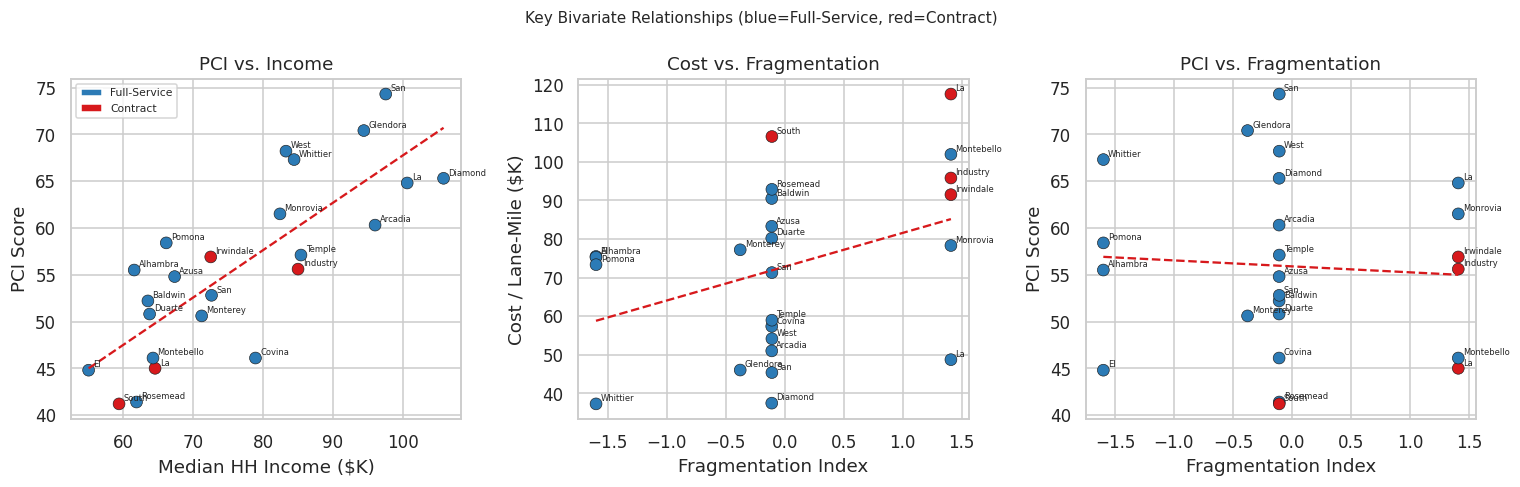

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
colors = ["#d7191c" if c == "Contract" else "#2c7bb6" for c in panel["city_class"]]

# PCI vs income
axes[0].scatter(panel["median_hh_income"] / 1000, panel["pci_score"],
                c=colors, s=60, edgecolors="k", linewidth=0.4)
for _, row in panel.iterrows():
    axes[0].annotate(row["name"].split()[0],
                     (row["median_hh_income"] / 1000, row["pci_score"]),
                     fontsize=5.5, xytext=(3, 2), textcoords="offset points")
m, b = np.polyfit(panel["median_hh_income"] / 1000, panel["pci_score"], 1)
xx = np.linspace(panel["median_hh_income"].min()/1000, panel["median_hh_income"].max()/1000, 100)
axes[0].plot(xx, m*xx+b, color="#d7191c", lw=1.5, ls="--")
axes[0].set_xlabel("Median HH Income ($K)")
axes[0].set_ylabel("PCI Score")
axes[0].set_title("PCI vs. Income")

# Cost vs fragmentation
axes[1].scatter(panel["fragmentation_idx"], panel["cost_per_lane_mile"] / 1000,
                c=colors, s=60, edgecolors="k", linewidth=0.4)
for _, row in panel.iterrows():
    axes[1].annotate(row["name"].split()[0],
                     (row["fragmentation_idx"], row["cost_per_lane_mile"] / 1000),
                     fontsize=5.5, xytext=(3, 2), textcoords="offset points")
m2, b2 = np.polyfit(panel["fragmentation_idx"], panel["cost_per_lane_mile"] / 1000, 1)
xx2 = np.linspace(panel["fragmentation_idx"].min(), panel["fragmentation_idx"].max(), 100)
axes[1].plot(xx2, m2*xx2+b2, color="#d7191c", lw=1.5, ls="--")
axes[1].set_xlabel("Fragmentation Index")
axes[1].set_ylabel("Cost / Lane-Mile ($K)")
axes[1].set_title("Cost vs. Fragmentation")

# PCI vs fragmentation
axes[2].scatter(panel["fragmentation_idx"], panel["pci_score"],
                c=colors, s=60, edgecolors="k", linewidth=0.4)
for _, row in panel.iterrows():
    axes[2].annotate(row["name"].split()[0],
                     (row["fragmentation_idx"], row["pci_score"]),
                     fontsize=5.5, xytext=(3, 2), textcoords="offset points")
m3, b3 = np.polyfit(panel["fragmentation_idx"], panel["pci_score"], 1)
axes[2].plot(xx2, m3*xx2+b3, color="#d7191c", lw=1.5, ls="--")
axes[2].set_xlabel("Fragmentation Index")
axes[2].set_ylabel("PCI Score")
axes[2].set_title("PCI vs. Fragmentation")

from matplotlib.patches import Patch
legend = [Patch(facecolor="#2c7bb6", label="Full-Service"),
          Patch(facecolor="#d7191c", label="Contract")]
axes[0].legend(handles=legend, fontsize=7)

plt.suptitle("Key Bivariate Relationships (blue=Full-Service, red=Contract)", fontsize=10)
plt.tight_layout()
plt.show()


## 8  SFA Efficiency Scores

In [12]:
display(sfa.sort_values("te_rank")[
    ["te_rank", "name", "city_class", "te_score",
     "inefficiency_pct", "fragmentation_idx", "median_hh_income"]
].reset_index(drop=True))


,te_rank,name,city_class,te_score,inefficiency_pct,fragmentation_idx,median_hh_income
0,1,Arcadia,Full-Service,1.0000,0.00,-0.109307,96028
1,1,Monterey Park,Full-Service,1.0000,0.00,-0.376580,71202
2,3,Industry,Contract,0.9999,0.01,1.408270,85000
3,4,Pomona,Full-Service,0.9983,0.17,-1.597748,66129
4,5,Baldwin Park,Full-Service,0.9816,1.84,-0.109307,63504
5,6,Rosemead,Full-Service,0.9802,1.98,-0.108094,61875
6,7,Alhambra,Full-Service,0.9701,2.99,-1.598281,61542
7,8,Azusa,Full-Service,0.9648,3.52,-0.109307,67331
8,9,Temple City,Full-Service,0.9626,3.74,-0.108094,85417
9,10,Monrovia,Full-Service,0.9624,3.76,1.408270,82411


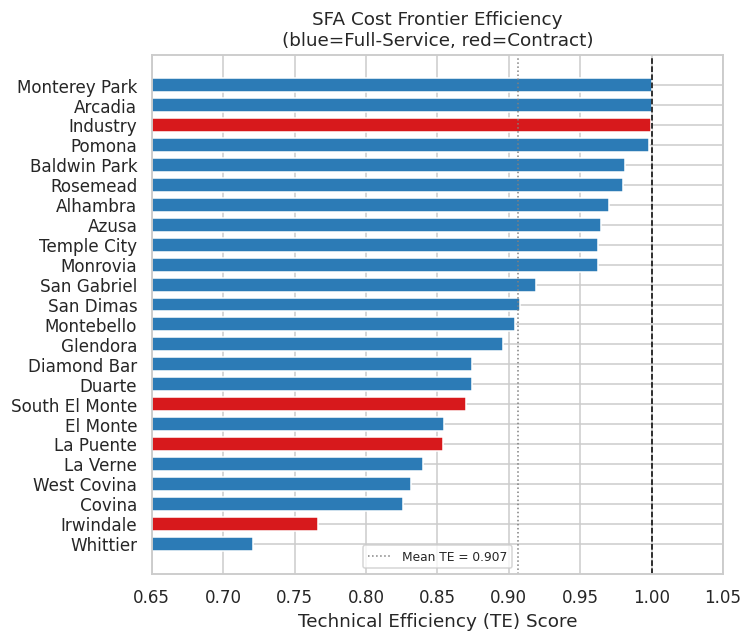

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
sfa_sorted = sfa.sort_values("te_score")
bar_colors = ["#d7191c" if c == "Contract" else "#2c7bb6"
              for c in sfa_sorted["city_class"]]
ax.barh(sfa_sorted["name"], sfa_sorted["te_score"],
        color=bar_colors, edgecolor="white", height=0.7)
ax.axvline(1.0, color="black", lw=1, ls="--")
ax.axvline(sfa_sorted["te_score"].mean(), color="grey", lw=1, ls=":",
           label=f"Mean TE = {sfa_sorted['te_score'].mean():.3f}")
ax.set_xlabel("Technical Efficiency (TE) Score")
ax.set_title("SFA Cost Frontier Efficiency\n(blue=Full-Service, red=Contract)")
ax.legend(fontsize=8)
ax.set_xlim(0.65, 1.05)
plt.tight_layout()
plt.show()


## 9  Pandas Profiling — Phase 2 Analytical Panel

Full `ydata-profiling` report on the 24-city panel.
The report is saved to `data/output/phase2/panel_profile.html` and displayed inline.


In [14]:
def profile_dataframe(df: pd.DataFrame,
                      title: str = "Dataset Profile",
                      output_path: str | None = None,
                      minimal: bool = False) -> "ProfileReport":
    """
    Generate a ydata-profiling ProfileReport for any DataFrame.

    Parameters
    ----------
    df          : DataFrame to profile.
    title       : Report title shown in the HTML output.
    output_path : If provided, save the HTML report to this path.
    minimal     : Use minimal mode (faster, fewer correlations).

    Returns
    -------
    ProfileReport object (can be displayed inline in Jupyter).
    """
    from ydata_profiling import ProfileReport

    report = ProfileReport(
        df,
        title=title,
        minimal=minimal,
        explorative=not minimal,
        correlations={
            "pearson":  {"calculate": True},
            "spearman": {"calculate": True},
            "kendall":  {"calculate": False},
            "phi_k":    {"calculate": False},
        },
        missing_diagrams={"bar": True, "matrix": False, "heatmap": False},
        progress_bar=False,
    )

    if output_path:
        report.to_file(output_path)
        print(f"Profile saved → {output_path}")

    return report


In [15]:
# Profile the main analytical panel (drop non-numeric / ID columns)
panel_for_profile = panel.drop(
    columns=["pci_source", "cost_source", "income_quartile"], errors="ignore"
)

profile = profile_dataframe(
    panel_for_profile,
    title="SGV Pilot — Phase 2 Analytical Panel (n=24)",
    output_path=str(P2 / "panel_profile.html"),
    minimal=False,
)

profile


  0%|          | 0/21 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 338.35it/s]

Profile saved → data/output/phase2/panel_profile.html


ModuleNotFoundError: No module named 'ipywidgets'

## 10  Pandas Profiling — Income Dataset

In [16]:
income_for_profile = income.drop(
    columns=["source", "income_quartile"], errors="ignore"
)

income_profile = profile_dataframe(
    income_for_profile,
    title="SGV Pilot — Income by Jurisdiction (ACS 2023, n=24)",
    output_path=str(ROOT / "income_profile.html"),
    minimal=True,
)

income_profile


  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 38130.04it/s]

Profile saved → data/output/income_profile.html


ModuleNotFoundError: No module named 'ipywidgets'

## 11  Quick Reference — Key Statistics

In [17]:
print("=" * 56)
print("  SGV PILOT — KEY STATISTICS AT A GLANCE")
print("=" * 56)

stats = {
    "Cities (n)":                   len(panel),
    "Contract cities":              (panel["city_class"] == "Contract").sum(),
    "Full-Service cities":          (panel["city_class"] == "Full-Service").sum(),
    "":                             "",
    "PCI — mean":                   f"{panel['pci_score'].mean():.1f}",
    "PCI — std":                    f"{panel['pci_score'].std():.1f}",
    "PCI — range":                  f"{panel['pci_score'].min():.0f} – {panel['pci_score'].max():.0f}",
    " ":                            "",
    "Cost/LM — mean ($K)":          f"{panel['cost_per_lane_mile'].mean()/1000:.1f}",
    "Cost/LM — std ($K)":           f"{panel['cost_per_lane_mile'].std()/1000:.1f}",
    "Cost/LM — range ($K)":         f"{panel['cost_per_lane_mile'].min()/1000:.0f} – {panel['cost_per_lane_mile'].max()/1000:.0f}",
    "  ":                           "",
    "Fragmentation idx — mean":     f"{panel['fragmentation_idx'].mean():.3f}",
    "Fragmentation idx — std":      f"{panel['fragmentation_idx'].std():.3f}",
    "Fragmentation idx — range":    f"{panel['fragmentation_idx'].min():.2f} – {panel['fragmentation_idx'].max():.2f}",
    "   ":                          "",
    "Median HH income — mean ($K)": f"{panel['median_hh_income'].mean()/1000:.1f}",
    "Median HH income — range ($K)":f"{panel['median_hh_income'].min()/1000:.0f} – {panel['median_hh_income'].max()/1000:.0f}",
    "Poverty rate — mean (%)":      f"{panel['poverty_rate'].mean():.1f}",
    "    ":                         "",
    "SFA mean efficiency":          f"{sfa['te_score'].mean():.3f}",
    "SFA avg avoidable cost":       f"{sfa['inefficiency_pct'].mean():.1f}%",
    "Road segments (mesh)":         f"{len(mesh):,}",
    "Boundary centerlines":         f"{mesh['is_boundary'].sum()} ({mesh['is_boundary'].mean()*100:.1f}%)",
}

for k, v in stats.items():
    if v == "":
        print()
    else:
        print(f"  {k:<35} {v}")


  SGV PILOT — KEY STATISTICS AT A GLANCE
  Cities (n)                          24
  Contract cities                     4
  Full-Service cities                 20

  PCI — mean                          55.9
  PCI — std                           9.3
  PCI — range                         41 – 74

  Cost/LM — mean ($K)                 72.8
  Cost/LM — std ($K)                  22.5
  Cost/LM — range ($K)                37 – 118

  Fragmentation idx — mean            -0.000
  Fragmentation idx — std             0.990
  Fragmentation idx — range           -1.60 – 1.41

  Median HH income — mean ($K)        76.6
  Median HH income — range ($K)       55 – 106
  Poverty rate — mean (%)             10.6

  SFA mean efficiency                 0.907
  SFA avg avoidable cost              9.3%
  Road segments (mesh)                7,149
  Boundary centerlines                37 (0.5%)
